# Self-Refine on the small tier

The analysis is restricted to the **small tier** (12–14B: Gemma 3 12B,
Ministral 3 14B, Qwen3 14B). The experiment is self-play: in every game both
seats are the same model, and each of the four strategy assignments is run
30 times per model. The assignments are coded by two letters, the first for
Player 1 and the second for Player 2, with `D` = default and `R` = self-refine:

| code | Player 1 | Player 2 |
|------|----------|----------|
| `DD` | default  | default  |
| `RD` | refine   | default  |
| `DR` | default  | refine   |
| `RR` | refine   | refine   |

In [82]:
import sys, os, json, warnings
from pathlib import Path


def find_repo_root():
    starts = []
    seen = set()

    def add_start(path_like):
        if not path_like:
            return
        try:
            path = Path(path_like).resolve()
        except (FileNotFoundError, OSError, RuntimeError):
            return
        key = str(path)
        if key not in seen:
            seen.add(key)
            starts.append(path)

    if "__file__" in globals():
        add_start(Path(__file__).resolve().parent)
    try:
        add_start(Path.cwd())
    except (FileNotFoundError, OSError, RuntimeError):
        pass
    add_start(os.environ.get("PWD"))
    for start in starts:
        for candidate in (start, *start.parents):
            if ((candidate / ".logs").exists()
                    and (candidate / "configs").exists()
                    and (candidate / "_notebooks").exists()):
                return candidate
    raise FileNotFoundError("Could not find repository root")


ROOT_DIR = find_repo_root()
sys.path.insert(0, str(ROOT_DIR))
sys.path.insert(0, str(ROOT_DIR / "_notebooks" / "oss" / "style"))
sys.path.insert(0, str(ROOT_DIR / "explorer"))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.filterwarnings("ignore")

import style
from style import wilson_ci, bootstrap_ci, errbars_from_ci, win_rate, family_of
# Publication design system (_notebooks/oss/style): sans-serif report skin,
# colorblind palette, value-axis gridlines, and constrained layout.
style.apply_thesis_style()
FULL_WIDTH, HALF_WIDTH = style.FULL_WIDTH, style.HALF_WIDTH

NOTEBOOK_NAME = "3_self_refine"
FIG_DIR = ROOT_DIR / "_notebooks" / "oss" / "figures" / NOTEBOOK_NAME
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_plot(fig, slug):
    """Save without the descriptive whole-figure title (the LaTeX caption supplies
    it); keep panel titles and keep the title for the inline display. Writes a PNG."""
    hidden = []
    sup = getattr(fig, "_suptitle", None)
    if sup is not None and sup.get_text():
        sup.set_visible(False); hidden.append(sup)
    real_axes = [a for a in fig.axes if a.get_label() != "<colorbar>"]
    if len(real_axes) == 1 and real_axes[0].get_title():
        t = real_axes[0].title
        t.set_visible(False); hidden.append(t)
    for ext in ("png",):
        fig.savefig(FIG_DIR / f"{slug}.{ext}", dpi=300, bbox_inches="tight")
    for artist in hidden:
        artist.set_visible(True)
    return FIG_DIR / f"{slug}.png"


def print_plot_frame(name, df, columns=None, sort_by=None, round_cols=None):
    out = df.copy()
    if columns is not None:
        out = out.loc[:, columns]
    if sort_by is not None:
        out = out.sort_values(sort_by).reset_index(drop=True)
    if round_cols:
        for col, digits in round_cols.items():
            if col in out.columns:
                out[col] = out[col].round(digits)
    print(f"PLOT_DATA[{name}]")
    print(out.to_json(orient="records"))


SIZE = "small"
GAME_ORDER = ["Trading", "Ultimatum", "BuySell"]
COND_ORDER = ["DD", "RD", "DR", "RR"]
COND_LABEL = {"DD": "default", "RD": "refine P1", "DR": "refine P2", "RR": "both refine"}
# Strategy-condition palette (grey baseline, blue single-seat refine, green both).
COND_COLORS = {"DD": "#de8f05", "RD": "#0173b2", "DR": "#0173b2", "RR": "#029e73"}
# Focal-party setting palette for the seat-controlled comparison.
SETTING_ORDER = ["default", "refine", "both"]
SETTING_LABEL = {"default": "default", "refine": "refine (one seat)", "both": "both refine"}
SETTING_COLORS = {"default": "#de8f05", "refine": "#0173b2", "both": "#029e73"}
# Process direction palette (matches the Streamlit page).
DIRECTION_ORDER = ["more_selfish", "unchanged", "more_generous", "no_proposal"]
DIRECTION_LABEL = {"more_selfish": "more selfish", "unchanged": "unchanged",
                   "more_generous": "more generous", "no_proposal": "no proposal"}
DIRECTION_COLORS = {"more_selfish": "#de8f05", "unchanged": "#0173b2",
                    "more_generous": "#029e73", "no_proposal": "#949494"}
GAME_NATIVE_UNIT = {"Trading": "resource delta", "Ultimatum": "dollars kept",
                    "BuySell": "surplus (ZUP)"}

# Lowercase game keys as they appear in the trace frames (TRACE/TSUM), plus a
# display map back to the title-case names used everywhere else.
games_l = ["trading", "ultimatum", "buysell"]
game_disp = {"trading": "Trading", "ultimatum": "Ultimatum", "buysell": "BuySell"}


In [83]:
from analysis.self_refine import (
    load_trading_sr, load_ultimatum_sr, load_buysell_sr, completion_rows,
)
from analysis.self_refine_process import load_trace_rows, load_trace_summary

OUT = {
    "Trading": load_trading_sr(SIZE),
    "Ultimatum": load_ultimatum_sr(SIZE),
    "BuySell": load_buysell_sr(SIZE),
}
for g, df in OUT.items():
    df["game"] = g
    df["family"] = df["model"].map(family_of)

COMP = completion_rows(SIZE)
TRACE = load_trace_rows()
TRACE = TRACE[TRACE["size"] == SIZE].copy()
TSUM = load_trace_summary()
TSUM = TSUM[TSUM["size"] == SIZE].copy()

# Sample sizes: completed decisive games underpin every win rate, so show them.
size_tbl = []
for g, df in OUT.items():
    for c in COND_ORDER:
        sub = df[df["cond"] == c]
        decisive = int((sub["win_1"] | sub["win_2"]).sum())
        size_tbl.append({"game": g, "cond": c, "completed": len(sub),
                         "decisive": decisive})
size_tbl = pd.DataFrame(size_tbl).pivot_table(
    index="game", columns="cond", values=["completed", "decisive"]).reindex(GAME_ORDER)
print("Completed runs / decisive (non-tied) games per game x condition:\n")
print(size_tbl.to_string())

# One row per refined trace, with the offer-drift / stability / direction
# metrics used by the mechanism sections.
proc = TSUM


2026-06-16 13:32:15.306 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 13:32:18.062 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Completed runs / decisive (non-tied) games per game x condition:

          completed                   decisive                  
cond             DD    DR    RD    RR       DD    DR    RD    RR
game                                                            
Trading        73.0  88.0  86.0  84.0     57.0  73.0  78.0  76.0
Ultimatum      80.0  89.0  83.0  78.0     59.0  67.0  59.0  62.0
BuySell        84.0  88.0  87.0  87.0     70.0  82.0  78.0  85.0


## 1. Completion

One of the five critique axes is *format*: whether every required tag is present
and parseable.

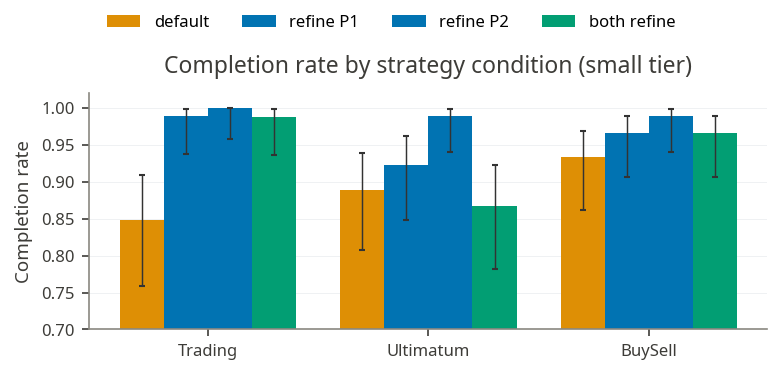

PLOT_DATA[completion_by_condition]
[{"game":"BuySell","cond":"DD","k":84,"n":90,"rate":0.933333,"lo":0.862099,"hi":0.96909},{"game":"BuySell","cond":"DR","k":89,"n":90,"rate":0.988889,"lo":0.939716,"hi":0.998036},{"game":"BuySell","cond":"RD","k":87,"n":90,"rate":0.966667,"lo":0.906527,"hi":0.9886},{"game":"BuySell","cond":"RR","k":87,"n":90,"rate":0.966667,"lo":0.906527,"hi":0.9886},{"game":"Trading","cond":"DD","k":73,"n":86,"rate":0.848837,"lo":0.758364,"hi":0.909479},{"game":"Trading","cond":"DR","k":88,"n":88,"rate":1.0,"lo":0.958173,"hi":1.0},{"game":"Trading","cond":"RD","k":86,"n":87,"rate":0.988506,"lo":0.937728,"hi":0.997968},{"game":"Trading","cond":"RR","k":84,"n":85,"rate":0.988235,"lo":0.936328,"hi":0.99792},{"game":"Ultimatum","cond":"DD","k":80,"n":90,"rate":0.888889,"lo":0.807422,"hi":0.938517},{"game":"Ultimatum","cond":"DR","k":89,"n":90,"rate":0.988889,"lo":0.939716,"hi":0.998036},{"game":"Ultimatum","cond":"RD","k":83,"n":90,"rate":0.922222,"lo":0.848061,"hi":0.961

In [84]:
cc = (COMP.groupby(["game", "cond"])
      .agg(k=("completed", "sum"), n=("completed", "count")).reset_index())
cc["rate"] = cc["k"] / cc["n"]
cc[["lo", "hi"]] = cc.apply(lambda r: pd.Series(wilson_ci(r.k, r.n)), axis=1)

x = np.arange(len(GAME_ORDER)); width = 0.2
fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.85, 2.4))
for i, c in enumerate(COND_ORDER):
    sub = cc[cc["cond"] == c].set_index("game").reindex(GAME_ORDER)
    pos = x + (i - 1.5) * width
    ax.bar(pos, sub["rate"], width, label=COND_LABEL[c], color=COND_COLORS[c])
    ax.errorbar(pos, sub["rate"],
                yerr=errbars_from_ci(sub["rate"].values, list(zip(sub["lo"], sub["hi"]))),
                fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
ax.set_xticks(x, GAME_ORDER); ax.set_ylabel("Completion rate"); ax.set_ylim(0.7, 1.02)
ax.set_title("Completion rate by strategy condition (small tier)")
fig.legend(*ax.get_legend_handles_labels(), loc="outside upper center", ncols=4, frameon=False)
save_plot(fig, "completion_by_condition"); 
plt.show()

print_plot_frame(
    "completion_by_condition",
    cc,
    columns=["game", "cond", "k", "n", "rate", "lo", "hi"],
    sort_by=["game", "cond"],
    round_cols={"rate": 6, "lo": 6, "hi": 6},
)

Self-Refine lifts completion in every game

## 2. Refining the first mover is not the same as refining the second

This section compares each seat against its own seat-matched `DD` baseline:

- **refine P1** is Player 1 in `RD` versus Player 1 in `DD`,
- **refine P2** is Player 2 in `DR` versus Player 2 in `DD`,
- **both refine** is each seat read from `RR`.

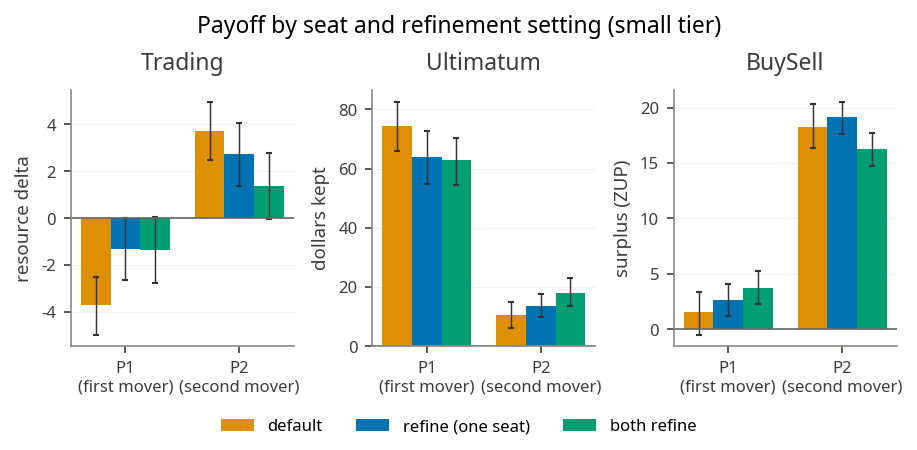

PLOT_DATA[refine_effect_by_seat]
[{"game":"BuySell","seat":1,"setting":"both","n":87,"mean":3.770115,"lo":2.298851,"hi":5.264368},{"game":"BuySell","seat":1,"setting":"default","n":84,"mean":1.547619,"lo":-0.464286,"hi":3.416667},{"game":"BuySell","seat":1,"setting":"refine","n":87,"mean":2.678161,"lo":1.229885,"hi":4.103448},{"game":"BuySell","seat":2,"setting":"both","n":87,"mean":16.229885,"lo":14.735632,"hi":17.701149},{"game":"BuySell","seat":2,"setting":"default","n":84,"mean":18.214286,"lo":16.309226,"hi":20.285714},{"game":"BuySell","seat":2,"setting":"refine","n":88,"mean":19.102273,"lo":17.625,"hi":20.534375},{"game":"Trading","seat":1,"setting":"both","n":84,"mean":-1.345238,"lo":-2.750298,"hi":0.059524},{"game":"Trading","seat":1,"setting":"default","n":73,"mean":-3.69863,"lo":-4.959247,"hi":-2.493151},{"game":"Trading","seat":1,"setting":"refine","n":86,"mean":-1.302326,"lo":-2.627907,"hi":0.023256},{"game":"Trading","seat":2,"setting":"both","n":84,"mean":1.345238,"lo":-0

In [85]:
# Seat-resolved view: each seat's payoff under its own default (DD), under
# refining only that seat (RD for P1, DR for P2), and under both refining (RR).
# Every comparison is against the seat-matched DD baseline, so no first/second
# mover asymmetry leaks in -- and the P1 and P2 effects stay separate.
SEAT_SETTING = ["default", "refine", "both"]  # reuse SETTING_* palette/labels

def seat_payoff(df, seat, setting):
    col = "payoff_1" if seat == 1 else "payoff_2"
    cond = {(1, "default"): "DD", (1, "refine"): "RD", (1, "both"): "RR",
            (2, "default"): "DD", (2, "refine"): "DR", (2, "both"): "RR"}[(seat, setting)]
    return df[df["cond"] == cond][col].values.astype(float)

def seat_winrate(df, seat, setting):
    cond = {(1, "default"): "DD", (1, "refine"): "RD", (1, "both"): "RR",
            (2, "default"): "DD", (2, "refine"): "DR", (2, "both"): "RR"}[(seat, setting)]
    sub = df[df["cond"] == cond]
    if seat == 1:
        w, l = int(sub["win_1"].sum()), int(sub["win_2"].sum())
    else:
        w, l = int(sub["win_2"].sum()), int(sub["win_1"].sum())
    rate, k, n = win_rate(w, l)
    return rate, k, n

def _diff_ci(ref, base, n=4000, seed=0):
    ref, base = np.asarray(ref, float), np.asarray(base, float)
    rng = np.random.default_rng(seed)
    d = [rng.choice(ref, ref.size).mean() - rng.choice(base, base.size).mean()
         for _ in range(n)]
    return float(np.percentile(d, 2.5)), float(np.percentile(d, 97.5))

# Figure: one panel per game; within a panel, two seat groups (P1, P2), each with
# default / refine-this-seat / both bars carrying bootstrap CIs.
seat_plot = []
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.9))
group_x = np.arange(2); width = 0.26
for ax, g in zip(axes, GAME_ORDER):
    df = OUT[g]
    for i, s in enumerate(SEAT_SETTING):
        centers, los, his = [], [], []
        for seat in (1, 2):
            vals = seat_payoff(df, seat, s)
            center = np.mean(vals)
            centers.append(center)
            lo, hi = bootstrap_ci(vals)
            seat_plot.append(dict(game=g, seat=seat, setting=s, n=len(vals), mean=center, lo=lo, hi=hi))
            los.append(lo); his.append(hi)
        pos = group_x + (i - 1) * width
        ax.bar(pos, centers, width, label=SETTING_LABEL[s], color=SETTING_COLORS[s])
        ax.errorbar(pos, centers,
                    yerr=errbars_from_ci(centers, list(zip(los, his))),
                    fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
    ax.axhline(0, lw=0.8, color="0.4")
    ax.set_xticks(group_x, ["P1\n(first mover)", "P2\n(second mover)"])
    ax.set_title(g); ax.set_ylabel(GAME_NATIVE_UNIT[g])
fig.suptitle("Payoff by seat and refinement setting (small tier)")
# Legend at the bottom so it never collides with the whole-figure title up top.
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
           ncols=3, frameon=False)
save_plot(fig, "refine_effect_by_seat"); plt.show()

print_plot_frame(
    "refine_effect_by_seat",
    pd.DataFrame(seat_plot),
    columns=["game", "seat", "setting", "n", "mean", "lo", "hi"],
    sort_by=["game", "seat", "setting"],
    round_cols={"mean": 6, "lo": 6, "hi": 6},
)

# Seat-specific effect: refine-this-seat minus the seat-matched DD baseline,
# with a bootstrap CI on the difference, plus the win-rate shift.
print("Seat-specific refine effect (refine that seat - DD baseline, same seat):\n")
print(f"{'game':10s} {'seat':5s} {'default':>8s} {'refine':>8s} {'delta':>8s} "
      f"{'95% CI':>16s}   {'winrate D->R':>14s}")
for g in GAME_ORDER:
    df = OUT[g]
    for seat in (1, 2):
        base = seat_payoff(df, seat, "default")
        ref = seat_payoff(df, seat, "refine")
        lo, hi = _diff_ci(ref, base)
        bwr, _, _ = seat_winrate(df, seat, "default")
        rwr, _, _ = seat_winrate(df, seat, "refine")
        tag = "P1" if seat == 1 else "P2"
        print(f"{g:10s} {tag:5s} {base.mean():8.2f} {ref.mean():8.2f} "
              f"{ref.mean()-base.mean():+8.2f} [{lo:+6.2f},{hi:+6.2f}]   "
              f"{bwr:5.2f} -> {rwr:4.2f}")


- In **Trading**, where the first mover loses on default (P1 keeps −3.7 in
`DD`), refining only P1 is the one clearly positive intervention in the notebook:
payoff rises +2.40 [+0.57, +4.21] and P1's win rate climbs 0.18 → 0.38, an
interval that clears zero. Refining the already-winning P2 in the same game does
nothing or slightly hurts (−0.98 [−2.77, +0.79]). 

-**Ultimatum** is the mirror image: the dominant proposer (P1 keeps ~75 on default) *loses* about ten dollars
from refining (−10.60 [−22.67, +1.82]) — the loop talks it into a more generous
split it cannot recover — while the responder gains a little (+3.08). 

- **BuySell** is the only game where the two seats agree, both nudging up by about a point with
intervals straddling zero. Pooling P1-of-`RD` with P2-of-`DR` was averaging a
helped loser against a hurt winner, which is exactly why Section 2 read as flat.

The takeaway is that refinement tends to pull whichever
seat runs it toward the *middle* — lifting the disadvantaged first mover in
Trading, dragging the dominant proposer down in Ultimatum — rather than uniformly
helping the party that pays for it.

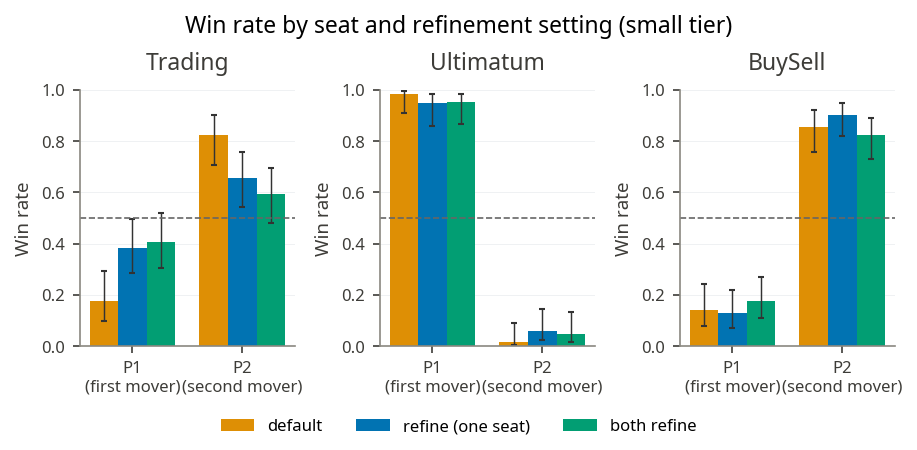

PLOT_DATA[winrate_refine_effect_by_seat]
[{"game":"BuySell","seat":1,"setting":"both","k":15,"n":85,"rate":0.176471,"lo":0.109964,"hi":0.270956},{"game":"BuySell","seat":1,"setting":"default","k":10,"n":70,"rate":0.142857,"lo":0.079489,"hi":0.243384},{"game":"BuySell","seat":1,"setting":"refine","k":10,"n":78,"rate":0.128205,"lo":0.071153,"hi":0.22016},{"game":"BuySell","seat":2,"setting":"both","k":70,"n":85,"rate":0.823529,"lo":0.729044,"hi":0.890036},{"game":"BuySell","seat":2,"setting":"default","k":60,"n":70,"rate":0.857143,"lo":0.756616,"hi":0.920511},{"game":"BuySell","seat":2,"setting":"refine","k":74,"n":82,"rate":0.902439,"lo":0.819128,"hi":0.949731},{"game":"Trading","seat":1,"setting":"both","k":31,"n":76,"rate":0.407895,"lo":0.304438,"hi":0.520214},{"game":"Trading","seat":1,"setting":"default","k":10,"n":57,"rate":0.175439,"lo":0.098189,"hi":0.293674},{"game":"Trading","seat":1,"setting":"refine","k":30,"n":78,"rate":0.384615,"lo":0.28449,"hi":0.495572},{"game":"Trading",

In [86]:
# Seat-resolved win rate: each seat's win rate (ties excluded) under its own
# default (DD), under refining only that seat (RD for P1, DR for P2), and under
# both refining (RR) -- the same comparisons as the payoff figure above, lifted
# from the printed table into a figure. The 0.5 line is parity: a seat neither
# helped nor hurt relative to a default opponent.
seat_wr = []
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.9))
group_x = np.arange(2); width = 0.26
for ax, g in zip(axes, GAME_ORDER):
    df = OUT[g]
    for i, s in enumerate(SEAT_SETTING):
        rates, los, his = [], [], []
        for seat in (1, 2):
            rate, k, n = seat_winrate(df, seat, s)
            lo, hi = wilson_ci(k, n)
            rates.append(rate); los.append(lo); his.append(hi)
            seat_wr.append(dict(game=g, seat=seat, setting=s, rate=rate,
                                k=k, n=n, lo=lo, hi=hi))
        pos = group_x + (i - 1) * width
        ax.bar(pos, rates, width, label=SETTING_LABEL[s], color=SETTING_COLORS[s])
        ax.errorbar(pos, rates,
                    yerr=errbars_from_ci(np.array(rates), list(zip(los, his))),
                    fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
    ax.axhline(0.5, ls="--", lw=0.8, color="0.4")
    ax.set_xticks(group_x, ["P1\n(first mover)", "P2\n(second mover)"])
    ax.set_title(g); ax.set_ylabel("Win rate"); ax.set_ylim(0, 1.0)
fig.suptitle("Win rate by seat and refinement setting (small tier)")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
           ncols=3, frameon=False)
save_plot(fig, "winrate_refine_effect_by_seat"); plt.show()

print_plot_frame(
    "winrate_refine_effect_by_seat",
    pd.DataFrame(seat_wr),
    columns=["game", "seat", "setting", "k", "n", "rate", "lo", "hi"],
    sort_by=["game", "seat", "setting"],
    round_cols={"rate": 6, "lo": 6, "hi": 6},
)


The win-rate view tells the same story as the payoff bars and sharpens it. In Trading, refining the losing first mover lifts P1 from 0.18 to 0.38 — the one clearly positive seat effect — while refining the already-winning P2 leaves it flat. In Ultimatum the dominant proposer's win rate slips when it refines and the responder's edges up, the two seats moving toward each other. BuySell is roughly symmetric. Wherever a seat starts away from parity, refinement tends to pull it back toward the 0.5 line rather than push it further ahead.

### Matched default-vs-refine scatter

The team notebook's diagonal scatter has a direct self-refine analogue: hold
`game x seat x family` fixed, put the seat's `DD` outcome on the x-axis and the
matched refined outcome on the y-axis. Points above the diagonal are gains from
refinement; points below it are losses. The payoff panel uses each game's payoff
span so Trading, Ultimatum, and BuySell sit on the same 0-1 scale.


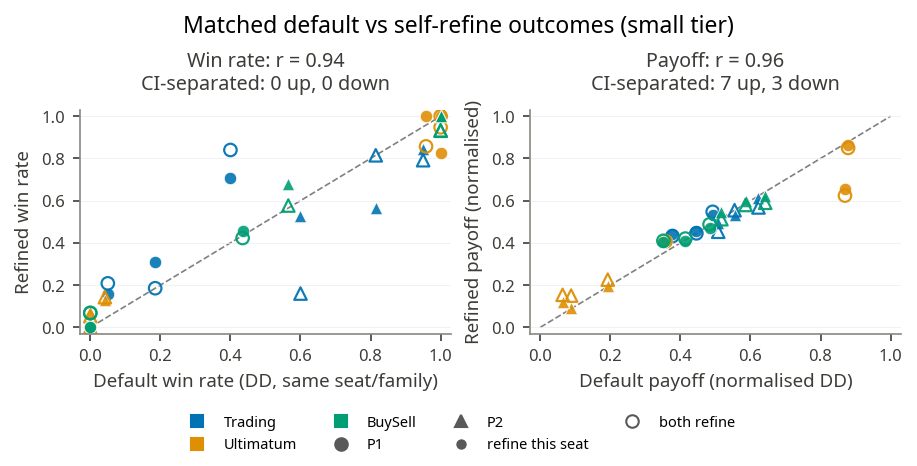

PLOT_DATA[default_vs_refine_scatter]
[{"game":"BuySell","family":"gemma","seat":1,"setting":"both","default_wr":0.0,"refined_wr":0.068966,"wr_delta":0.068966,"wr_rel":"overlap","default_pay":-4.866667,"refined_pay":1.0,"pay_delta":5.866667,"pay_lo":1.933333,"pay_hi":9.933333,"pay_rel":"refine>default","default_pay_norm":0.351333,"refined_pay_norm":0.41,"pay_norm_delta":0.058667},{"game":"BuySell","family":"gemma","seat":1,"setting":"refine","default_wr":0.0,"refined_wr":0.0,"wr_delta":0.0,"wr_rel":"overlap","default_pay":-4.866667,"refined_pay":0.206897,"pay_delta":5.073563,"pay_lo":1.407874,"pay_hi":9.037989,"pay_rel":"refine>default","default_pay_norm":0.351333,"refined_pay_norm":0.402069,"pay_norm_delta":0.050736},{"game":"BuySell","family":"ministral","seat":1,"setting":"both","default_wr":0.434783,"refined_wr":0.423077,"wr_delta":-0.011706,"wr_rel":"overlap","default_pay":8.310345,"refined_pay":8.777778,"pay_delta":0.467433,"pay_lo":-3.033365,"pay_hi":3.952842,"pay_rel":"overlap",

In [87]:
# Matched A/B scatter: default on x, refined condition on y. Each point is a
# game x seat x family cell. Filled markers isolate "refine this seat" (RD for
# P1, DR for P2); open markers show the bilateral RR condition.
from matplotlib.lines import Line2D

PAYOFF_BOUNDS = {"Trading": (-30, 30), "Ultimatum": (0, 100), "BuySell": (-40, 60)}
GAME_COLORS = {"Trading": "#0173b2", "Ultimatum": "#de8f05", "BuySell": "#029e73"}
FAMILY_ORDER = ["gemma", "ministral", "qwen"]
FAMILY_LABEL = {"gemma": "Gemma", "ministral": "Ministral", "qwen": "Qwen"}
SEAT_MARKER = {1: "o", 2: "^"}
COMPARE_SETTINGS = ["refine", "both"]
COMPARE_LABEL = {"refine": "refine this seat", "both": "both refine"}


def norm_payoff(game, payoff):
    lo, hi = PAYOFF_BOUNDS[game]
    return (payoff - lo) / (hi - lo)


def _seat_fam_payoff_values(df, seat, setting, fam):
    cond = {(1, "default"): "DD", (1, "refine"): "RD", (1, "both"): "RR",
            (2, "default"): "DD", (2, "refine"): "DR", (2, "both"): "RR"}[(seat, setting)]
    col = "payoff_1" if seat == 1 else "payoff_2"
    sub = df[(df["cond"] == cond) & (df["family"] == fam)]
    return sub[col].values.astype(float)


def _seat_fam_winrate(df, seat, setting, fam):
    cond = {(1, "default"): "DD", (1, "refine"): "RD", (1, "both"): "RR",
            (2, "default"): "DD", (2, "refine"): "DR", (2, "both"): "RR"}[(seat, setting)]
    sub = df[(df["cond"] == cond) & (df["family"] == fam)]
    if seat == 1:
        w, l = int(sub["win_1"].sum()), int(sub["win_2"].sum())
    else:
        w, l = int(sub["win_2"].sum()), int(sub["win_1"].sum())
    rate, k, n = win_rate(w, l)
    lo, hi = wilson_ci(k, n)
    return rate, k, n, lo, hi


def _relation_from_ci(diff_lo, diff_hi, better="refine"):
    if diff_lo > 0:
        return f"{better}>default"
    if diff_hi < 0:
        return f"{better}<default"
    return "overlap"


sr_rows = []
for g in GAME_ORDER:
    df = OUT[g]
    span = PAYOFF_BOUNDS[g][1] - PAYOFF_BOUNDS[g][0]
    for fam in FAMILY_ORDER:
        for seat in (1, 2):
            base_pay = _seat_fam_payoff_values(df, seat, "default", fam)
            base_wr, base_k, base_n, base_wr_lo, base_wr_hi = _seat_fam_winrate(df, seat, "default", fam)
            if len(base_pay) == 0:
                continue
            base_pay_mean = float(np.mean(base_pay))
            for setting in COMPARE_SETTINGS:
                ref_pay = _seat_fam_payoff_values(df, seat, setting, fam)
                ref_wr, ref_k, ref_n, ref_wr_lo, ref_wr_hi = _seat_fam_winrate(df, seat, setting, fam)
                if len(ref_pay) == 0:
                    continue
                ref_pay_mean = float(np.mean(ref_pay))
                pay_lo, pay_hi = _diff_ci(ref_pay, base_pay, seed=11 + seat + len(sr_rows))
                wr_rel = "refine>default" if ref_wr_lo > base_wr_hi else (
                    "refine<default" if base_wr_lo > ref_wr_hi else "overlap")
                sr_rows.append(dict(
                    game=g, family=fam, seat=seat, setting=setting,
                    default_wr=base_wr, refined_wr=ref_wr, wr_delta=ref_wr - base_wr,
                    default_wr_lo=base_wr_lo, default_wr_hi=base_wr_hi,
                    refined_wr_lo=ref_wr_lo, refined_wr_hi=ref_wr_hi,
                    wr_rel=wr_rel, default_k=base_k, default_n=base_n,
                    refined_k=ref_k, refined_n=ref_n,
                    default_pay=base_pay_mean, refined_pay=ref_pay_mean,
                    pay_delta=ref_pay_mean - base_pay_mean,
                    pay_lo=pay_lo, pay_hi=pay_hi,
                    pay_rel=_relation_from_ci(pay_lo, pay_hi),
                    default_pay_norm=norm_payoff(g, base_pay_mean),
                    refined_pay_norm=norm_payoff(g, ref_pay_mean),
                    pay_norm_delta=(ref_pay_mean - base_pay_mean) / span,
                    pay_norm_lo=pay_lo / span, pay_norm_hi=pay_hi / span,
                ))
SR_CMP = pd.DataFrame(sr_rows)

fig, (ax_wr, ax_pay) = plt.subplots(1, 2, figsize=(FULL_WIDTH, 3.0))
for ax in (ax_wr, ax_pay):
    ax.plot([0, 1], [0, 1], ls="--", color="0.5", lw=0.8, zorder=0)
    ax.set_xlim(-0.03, 1.03); ax.set_ylim(-0.03, 1.03)

for _, r in SR_CMP.iterrows():
    marker = SEAT_MARKER[int(r.seat)]
    color = GAME_COLORS[r.game]
    if r.setting == "refine":
        face, edge, lw, alpha = color, "white", 0.45, 0.9
    else:
        face, edge, lw, alpha = "none", color, 1.05, 0.95
    ax_wr.scatter(r.default_wr, r.refined_wr, s=36, marker=marker,
                  facecolors=face, edgecolors=edge, linewidth=lw, alpha=alpha, zorder=2)
    ax_pay.scatter(r.default_pay_norm, r.refined_pay_norm, s=36, marker=marker,
                   facecolors=face, edgecolors=edge, linewidth=lw, alpha=alpha, zorder=2)

wr_r = SR_CMP[["default_wr", "refined_wr"]].corr().iloc[0, 1]
pay_r = SR_CMP[["default_pay_norm", "refined_pay_norm"]].corr().iloc[0, 1]
wr_up = int((SR_CMP.wr_rel == "refine>default").sum())
wr_down = int((SR_CMP.wr_rel == "refine<default").sum())
pay_up = int((SR_CMP.pay_rel == "refine>default").sum())
pay_down = int((SR_CMP.pay_rel == "refine<default").sum())

ax_wr.set_xlabel("Default win rate (DD, same seat/family)")
ax_wr.set_ylabel("Refined win rate")
ax_wr.set_title(f"Win rate: r = {wr_r:.2f}\nCI-separated: {wr_up} up, {wr_down} down", fontsize=9.5)
ax_pay.set_xlabel("Default payoff (normalised DD)")
ax_pay.set_ylabel("Refined payoff (normalised)")
ax_pay.set_title(f"Payoff: r = {pay_r:.2f}\nCI-separated: {pay_up} up, {pay_down} down", fontsize=9.5)

leg_game = [Line2D([], [], marker="s", ls="", color=GAME_COLORS[g], label=g) for g in GAME_ORDER]
leg_seat = [Line2D([], [], marker=SEAT_MARKER[s], ls="", color="0.35",
                   label=f"P{s}") for s in (1, 2)]
leg_setting = [
    Line2D([], [], marker="o", ls="", markerfacecolor="0.35", markeredgecolor="white",
           color="0.35", label="refine this seat"),
    Line2D([], [], marker="o", ls="", markerfacecolor="none", markeredgecolor="0.35",
           color="0.35", label="both refine"),
]
fig.legend(handles=leg_game + leg_seat + leg_setting, loc="outside lower center",
           ncols=4, frameon=False, fontsize=7)
fig.suptitle("Matched default vs self-refine outcomes (small tier)")
save_plot(fig, "default_vs_refine_scatter")
plt.show()

print_plot_frame(
    "default_vs_refine_scatter",
    SR_CMP,
    columns=["game", "family", "seat", "setting", "default_wr", "refined_wr",
             "wr_delta", "wr_rel", "default_pay", "refined_pay", "pay_delta",
             "pay_lo", "pay_hi", "pay_rel", "default_pay_norm", "refined_pay_norm",
             "pay_norm_delta"],
    sort_by=["game", "seat", "family", "setting"],
    round_cols={"default_wr": 6, "refined_wr": 6, "wr_delta": 6,
                "default_pay": 6, "refined_pay": 6, "pay_delta": 6,
                "pay_lo": 6, "pay_hi": 6, "default_pay_norm": 6,
                "refined_pay_norm": 6, "pay_norm_delta": 6},
)

print("\nMean matched deltas:")
for setting in COMPARE_SETTINGS:
    sub = SR_CMP[SR_CMP["setting"] == setting]
    print(f"{COMPARE_LABEL[setting]:16s}  win rate {sub.wr_delta.mean():+.3f}  "
          f"normalised payoff {sub.pay_norm_delta.mean():+.3f}")


The diagonal view makes the A/B interpretation explicit. Self-refine mostly
tracks the matched `DD` baseline, but the below/above-diagonal departures show
where it redistributes advantage rather than creating a uniform lift. The
normalised payoff panel is the more comparable payoff summary; the printed table
keeps the native payoff deltas and bootstrap intervals for each cell.


## 3. How does refinement change the move?

For each refined turn we parse the **offer the move puts on the table** from both
the initial draft and the committed move, then measure how the loop moved it:

```
ambition_delta = final_offer − initial_offer        # draft → committed move
```

A positive value means refinement pushed the offer in the proposer's own favour
(**more selfish**); a negative value means it gave ground (**more generous**).
BuySell is the one game where the same raw price means opposite things to the two
seats — a higher price helps the seller but hurts the buyer — so for the
**BuySell buyer** (the second mover, `turn_n == 1`) the sign is flipped,
`ambition_delta = −offer_delta`, which puts every seat back on the same
"positive = more selfish" scale.

- `|ambition_delta| < 0.5` → **unchanged**
- `ambition_delta > 0` → **more_selfish**
- `ambition_delta < 0` → **more_generous**
- no offer at either end → **no_proposal**

A refined move belongs to whichever seat ran the loop — recoverable from turn
parity, since the first mover acts on even turns and the second on odd. Splitting
the direction mix by seat asks whether the loop's tug toward self-interest is a
first-mover or a second-mover phenomenon.

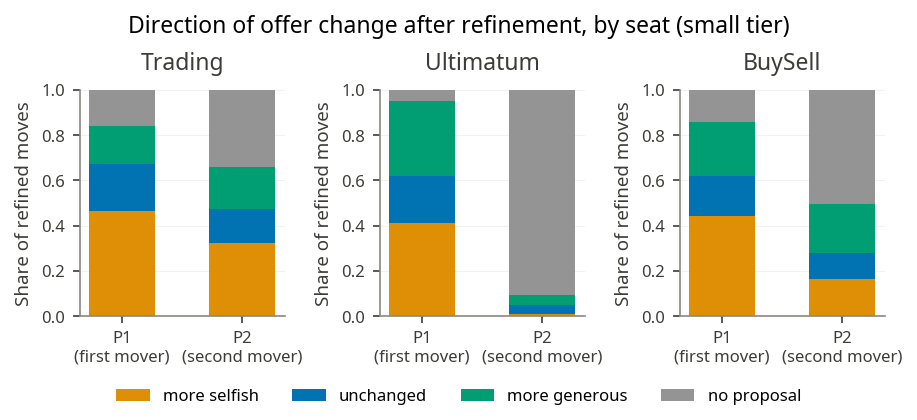

PLOT_DATA[refine_direction_by_seat]
[{"game":"buysell","seat":"P1","direction":"more_generous","n":62,"share":0.238462},{"game":"buysell","seat":"P1","direction":"more_selfish","n":115,"share":0.442308},{"game":"buysell","seat":"P1","direction":"no_proposal","n":37,"share":0.142308},{"game":"buysell","seat":"P1","direction":"unchanged","n":46,"share":0.176923},{"game":"buysell","seat":"P2","direction":"more_generous","n":45,"share":0.219512},{"game":"buysell","seat":"P2","direction":"more_selfish","n":34,"share":0.165854},{"game":"buysell","seat":"P2","direction":"no_proposal","n":103,"share":0.502439},{"game":"buysell","seat":"P2","direction":"unchanged","n":23,"share":0.112195},{"game":"trading","seat":"P1","direction":"more_generous","n":58,"share":0.170588},{"game":"trading","seat":"P1","direction":"more_selfish","n":158,"share":0.464706},{"game":"trading","seat":"P1","direction":"no_proposal","n":54,"share":0.158824},{"game":"trading","seat":"P1","direction":"unchanged","n":70,"sh

In [88]:
# Direction of offer change after refinement, split by the seat that refined.
# In self-play the first mover acts on even turns and the second on odd, so the
# refining seat is recoverable from turn parity (verified: RD traces are all
# even-turn, DR all odd-turn).
proc_seat = TSUM.copy()
proc_seat["seat"] = np.where(proc_seat["turn_n"] % 2 == 0, "P1", "P2")

dds = (proc_seat.groupby(["game", "seat", "direction"]).size()
       .rename("n").reset_index())
tot = dds.groupby(["game", "seat"])["n"].transform("sum")
dds["share"] = dds["n"] / tot

seats = ["P1", "P2"]
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.7))
xpos = np.arange(len(seats))
for ax, g in zip(axes, games_l):
    bottom = np.zeros(len(seats))
    for d in DIRECTION_ORDER:
        vals = []
        for seat in seats:
            row = dds[(dds["game"] == g) & (dds["seat"] == seat)
                      & (dds["direction"] == d)]
            vals.append(float(row["share"].iloc[0]) if len(row) else 0.0)
        vals = np.array(vals)
        ax.bar(xpos, vals, 0.55, bottom=bottom, label=DIRECTION_LABEL[d],
               color=DIRECTION_COLORS[d])
        bottom += vals
    ax.set_xticks(xpos, ["P1\n(first mover)", "P2\n(second mover)"])
    ax.set_ylim(0, 1.0); ax.set_title(game_disp[g])
    ax.set_ylabel("Share of refined moves")
fig.suptitle("Direction of offer change after refinement, by seat (small tier)")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
           ncols=4, frameon=False)
save_plot(fig, "refine_direction_by_seat"); plt.show()

print_plot_frame(
    "refine_direction_by_seat",
    dds,
    columns=["game", "seat", "direction", "n", "share"],
    sort_by=["game", "seat", "direction"],
    round_cols={"share": 6},
)


## 4. Seat × family

The closing section (Section 7) breaks the pooled effect down by model family but keeps both seats balanced. Re-opening that breakdown along the seat axis shows where each family's effect actually lives. Bars give the per-seat refine effect — refining that seat minus its own seat-matched `DD` baseline — with bootstrap intervals on the difference, one model per family at this tier.

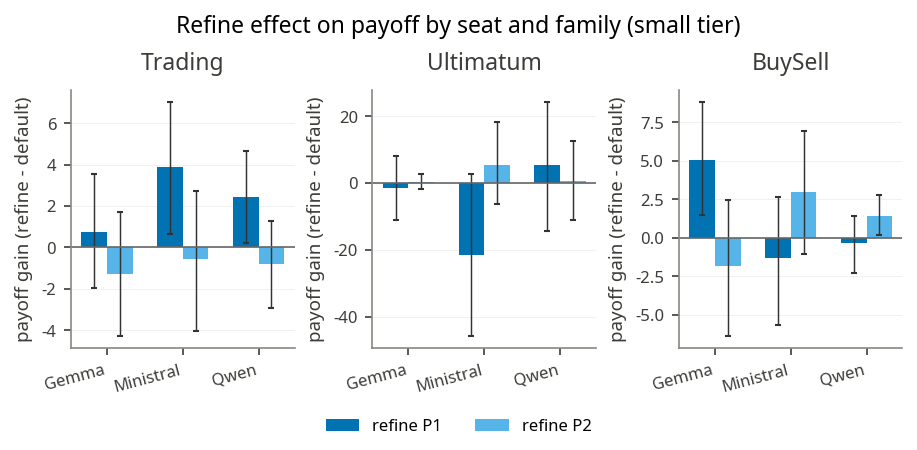

PLOT_DATA[refine_effect_by_family_seat]
[{"game":"BuySell","family":"gemma","seat":"P1","n":29,"delta":5.073563,"lo":1.47,"hi":8.845402},{"game":"BuySell","family":"ministral","seat":"P1","n":28,"delta":-1.310345,"lo":-5.658929,"hi":2.647876},{"game":"BuySell","family":"qwen","seat":"P1","n":30,"delta":-0.366667,"lo":-2.266667,"hi":1.400833},{"game":"BuySell","family":"gemma","seat":"P2","n":30,"delta":-1.833333,"lo":-6.366667,"hi":2.466667},{"game":"BuySell","family":"ministral","seat":"P2","n":28,"delta":2.953202,"lo":-1.061607,"hi":6.926847},{"game":"BuySell","family":"qwen","seat":"P2","n":30,"delta":1.4,"lo":0.2,"hi":2.8},{"game":"Trading","family":"gemma","seat":"P1","n":30,"delta":0.766667,"lo":-1.934167,"hi":3.533333},{"game":"Trading","family":"ministral","seat":"P1","n":27,"delta":3.882155,"lo":0.627862,"hi":7.043897},{"game":"Trading","family":"qwen","seat":"P1","n":29,"delta":2.441708,"lo":0.199959,"hi":4.666667},{"game":"Trading","family":"gemma","seat":"P2","n":30,"delta"

In [89]:
# Seat x family: the per-seat refine effect (refine that seat minus its own DD
# baseline) broken down by model family -- one model per family at this tier.
# This re-opens the pooled family bars of the closing section along the seat axis.
FAMILY_ORDER = ["gemma", "ministral", "qwen"]
FAMILY_LABEL = {"gemma": "Gemma", "ministral": "Ministral", "qwen": "Qwen"}
SEAT_EFFECT_COLORS = {"P1": "#0173b2", "P2": "#56b4e9"}

def _seat_fam_payoff(df, seat, setting, fam):
    cond = {(1, "default"): "DD", (1, "refine"): "RD",
            (2, "default"): "DD", (2, "refine"): "DR"}[(seat, setting)]
    col = "payoff_1" if seat == 1 else "payoff_2"
    sub = df[(df["cond"] == cond) & (df["family"] == fam)]
    return sub[col].values.astype(float)

sf_rows = []
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.9))
x = np.arange(len(FAMILY_ORDER)); width = 0.34
for ax, g in zip(axes, GAME_ORDER):
    df = OUT[g]
    for i, (seat, tag) in enumerate([(1, "P1"), (2, "P2")]):
        deltas, los, his = [], [], []
        for fam in FAMILY_ORDER:
            base = _seat_fam_payoff(df, seat, "default", fam)
            ref = _seat_fam_payoff(df, seat, "refine", fam)
            if len(base) and len(ref):
                d = ref.mean() - base.mean(); lo, hi = _diff_ci(ref, base)
            else:
                d, lo, hi = np.nan, np.nan, np.nan
            deltas.append(d); los.append(lo); his.append(hi)
            sf_rows.append(dict(game=g, family=fam, seat=tag, n=len(ref),
                                delta=d, lo=lo, hi=hi))
        pos = x + (i - 0.5) * width
        ax.bar(pos, deltas, width, label=f"refine {tag}",
               color=SEAT_EFFECT_COLORS[tag])
        ax.errorbar(pos, deltas,
                    yerr=errbars_from_ci(np.array(deltas), list(zip(los, his))),
                    fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
    ax.axhline(0, lw=0.8, color="0.4")
    ax.set_xticks(x, [FAMILY_LABEL[f] for f in FAMILY_ORDER], rotation=15, ha="right")
    ax.set_title(g); ax.set_ylabel("payoff gain (refine - default)")
fig.suptitle("Refine effect on payoff by seat and family (small tier)")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
           ncols=2, frameon=False)
save_plot(fig, "refine_effect_by_family_seat"); plt.show()

print_plot_frame(
    "refine_effect_by_family_seat",
    pd.DataFrame(sf_rows),
    columns=["game", "family", "seat", "n", "delta", "lo", "hi"],
    sort_by=["game", "seat", "family"],
    round_cols={"delta": 6, "lo": 6, "hi": 6},
)


The seat split runs through the families too, and it explains the closing section's headline. Trading is the cleanest: refining the first mover helps every family (+0.8 Gemma, +3.9 Ministral, +2.4 Qwen) while refining the second mover costs every family about a point — here the seat, not the family, sets the sign. The Ministral-in-Ultimatum collapse from the closing figure is almost entirely a first-mover effect: a refining Ministral *proposer* loses about twenty dollars a game, while a refining Ministral *responder* gains a few, and Qwen's proposer gains. BuySell is where the family matters most — Gemma gains from refining P1, Qwen and Ministral from refining P2 — with no shared sign. So “who does refinement help” has no answer without naming both the model and the seat it occupies.